# Data Preparation & Class Balancing Pipeline
## Glaucoma Detection - Comparative Thesis Project

This notebook performs comprehensive data analysis and preparation including:

1. **Dataset Analysis** - Understand class distribution and imbalance
2. **Class Balancing Strategies** - Multiple approaches for handling imbalanced data
3. **Train/Val/Test Split Verification** - Ensure proper data splits
4. **Dataset Statistics** - Comprehensive analysis of image properties
5. **Balanced Data Export** - Prepare balanced datasets for training

### Architectures:
1. U-Net + DCNN Classifier
2. ResNet-50 + DCNN Classifier
3. U-Net + Canny Edge + DCNN Classifier
4. ResNet-50 + Canny Edge + DCNN Classifier

### Datasets:
- **EyePACS**: Classification (NRG/RG)
- **REFUGE2**: Segmentation masks

## 1. Setup and Imports

In [1]:
# Install required packages
!pip install opencv-python numpy matplotlib pandas seaborn scikit-learn imbalanced-learn tqdm pillow

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import json
from tqdm import tqdm
from collections import Counter
import shutil
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib style
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully!")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✓ Libraries imported successfully!
OpenCV version: 4.11.0
NumPy version: 1.26.4
Pandas version: 2.2.2


## 2. Dataset Analysis Class

Comprehensive class for analyzing dataset structure and class distribution

In [3]:
class DatasetAnalyzer:
    """
    Comprehensive dataset analyzer for medical imaging classification tasks
    """
    
    def __init__(self, base_dir: str):
        """
        Initialize analyzer
        
        Args:
            base_dir: Base directory containing train/test/validation folders
        """
        self.base_dir = Path(base_dir)
        self.splits = ['train', 'validation', 'test']
        self.classes = ['NRG', 'RG']  # No Referable Glaucoma, Referable Glaucoma
        self.image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tif']
        
        self.dataset_info = self._scan_dataset()
        
    def _scan_dataset(self) -> Dict:
        """
        Scan dataset directory structure and count images
        
        Returns:
            Dictionary with dataset statistics
        """
        info = {
            'splits': {},
            'total_images': 0,
            'class_distribution': {cls: 0 for cls in self.classes}
        }
        
        for split in self.splits:
            info['splits'][split] = {}
            
            # EyePACS dataset (classification)
            eyepac_path = self.base_dir / split / 'eyepac'
            
            if eyepac_path.exists():
                for cls in self.classes:
                    cls_path = eyepac_path / cls
                    if cls_path.exists():
                        # Count images
                        images = self._get_image_files(cls_path)
                        count = len(images)
                        
                        info['splits'][split][cls] = count
                        info['class_distribution'][cls] += count
                        info['total_images'] += count
                        
        return info
    
    def _get_image_files(self, directory: Path) -> List[Path]:
        """
        Get all image files in directory
        
        Args:
            directory: Directory path
            
        Returns:
            List of image file paths
        """
        images = []
        for ext in self.image_extensions:
            images.extend(list(directory.glob(f'*{ext}')))
            images.extend(list(directory.glob(f'*{ext.upper()}')))
        return images
    
    def calculate_class_weights(self) -> Dict[str, float]:
        """
        Calculate class weights for weighted loss function
        
        Formula: weight = total_samples / (n_classes * class_count)
        
        Returns:
            Dictionary mapping class names to weights
        """
        total = self.dataset_info['total_images']
        n_classes = len(self.classes)
        
        weights = {}
        for cls in self.classes:
            count = self.dataset_info['class_distribution'][cls]
            if count > 0:
                weights[cls] = total / (n_classes * count)
            else:
                weights[cls] = 1.0
                
        return weights
    
    def calculate_imbalance_ratio(self) -> float:
        """
        Calculate imbalance ratio (majority/minority)
        
        Returns:
            Imbalance ratio
        """
        counts = list(self.dataset_info['class_distribution'].values())
        if min(counts) == 0:
            return float('inf')
        return max(counts) / min(counts)
    
    def get_minority_majority_classes(self) -> Tuple[str, str]:
        """
        Identify minority and majority classes
        
        Returns:
            (minority_class, majority_class)
        """
        dist = self.dataset_info['class_distribution']
        minority = min(dist, key=dist.get)
        majority = max(dist, key=dist.get)
        return minority, majority
    
    def print_summary(self):
        """
        Print comprehensive dataset summary
        """
        print("="*80)
        print("DATASET ANALYSIS SUMMARY")
        print("="*80)
        print(f"\nBase Directory: {self.base_dir}")
        print(f"Total Images: {self.dataset_info['total_images']:,}")
        
        print("\n" + "-"*80)
        print("CLASS DISTRIBUTION")
        print("-"*80)
        
        for cls, count in self.dataset_info['class_distribution'].items():
            percentage = (count / self.dataset_info['total_images'] * 100) if self.dataset_info['total_images'] > 0 else 0
            print(f"  {cls:15s}: {count:6,} images ({percentage:5.2f}%)")
        
        minority, majority = self.get_minority_majority_classes()
        imbalance = self.calculate_imbalance_ratio()
        
        print(f"\n  Minority Class: {minority}")
        print(f"  Majority Class: {majority}")
        print(f"  Imbalance Ratio: {imbalance:.2f}:1")
        
        print("\n" + "-"*80)
        print("SPLIT DISTRIBUTION")
        print("-"*80)
        
        for split in self.splits:
            if split in self.dataset_info['splits']:
                split_data = self.dataset_info['splits'][split]
                total_split = sum(split_data.values())
                print(f"\n{split.upper()}:")
                for cls, count in split_data.items():
                    percentage = (count / total_split * 100) if total_split > 0 else 0
                    print(f"  {cls:15s}: {count:6,} images ({percentage:5.2f}%)")
                print(f"  {'TOTAL':15s}: {total_split:6,} images")
        
        print("\n" + "-"*80)
        print("RECOMMENDED CLASS WEIGHTS (for weighted loss)")
        print("-"*80)
        
        weights = self.calculate_class_weights()
        for cls, weight in weights.items():
            print(f"  {cls:15s}: {weight:.4f}")
        
        print("\n" + "="*80)
    
    def visualize_distribution(self, save_path: Optional[str] = None):
        """
        Create comprehensive visualization of class distribution
        
        Args:
            save_path: Path to save figure (optional)
        """
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Dataset Class Distribution Analysis', fontsize=16, fontweight='bold')
        
        # 1. Overall class distribution (pie chart)
        ax1 = axes[0, 0]
        dist = self.dataset_info['class_distribution']
        colors = ['#ff6b6b', '#4ecdc4']
        explode = (0.05, 0.05)
        
        ax1.pie(dist.values(), labels=dist.keys(), autopct='%1.1f%%',
                colors=colors, explode=explode, shadow=True, startangle=90)
        ax1.set_title('Overall Class Distribution', fontweight='bold', fontsize=12)
        
        # 2. Class distribution by split (bar chart)
        ax2 = axes[0, 1]
        splits_data = []
        for split in self.splits:
            if split in self.dataset_info['splits']:
                splits_data.append(self.dataset_info['splits'][split])
        
        df = pd.DataFrame(splits_data, index=[s.capitalize() for s in self.splits])
        df.plot(kind='bar', ax=ax2, color=colors, alpha=0.8)
        ax2.set_title('Class Distribution by Split', fontweight='bold', fontsize=12)
        ax2.set_xlabel('Split', fontweight='bold')
        ax2.set_ylabel('Number of Images', fontweight='bold')
        ax2.legend(title='Class')
        ax2.grid(axis='y', alpha=0.3)
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=0)
        
        # 3. Class distribution by split (stacked bar chart)
        ax3 = axes[1, 0]
        df.plot(kind='bar', stacked=True, ax=ax3, color=colors, alpha=0.8)
        ax3.set_title('Stacked Class Distribution by Split', fontweight='bold', fontsize=12)
        ax3.set_xlabel('Split', fontweight='bold')
        ax3.set_ylabel('Number of Images', fontweight='bold')
        ax3.legend(title='Class')
        ax3.grid(axis='y', alpha=0.3)
        plt.setp(ax3.xaxis.get_majorticklabels(), rotation=0)
        
        # 4. Imbalance ratio visualization
        ax4 = axes[1, 1]
        minority, majority = self.get_minority_majority_classes()
        imbalance = self.calculate_imbalance_ratio()
        
        # Show imbalance ratio as horizontal bar
        classes = list(dist.keys())
        counts = list(dist.values())
        
        bars = ax4.barh(classes, counts, color=colors, alpha=0.8)
        ax4.set_title('Class Imbalance Visualization', fontweight='bold', fontsize=12)
        ax4.set_xlabel('Number of Images', fontweight='bold')
        ax4.grid(axis='x', alpha=0.3)
        
        # Add value labels
        for i, (cls, count) in enumerate(zip(classes, counts)):
            ax4.text(count, i, f'  {count:,}', va='center', fontweight='bold')
        
        # Add imbalance ratio annotation
        ax4.text(0.95, 0.05, f'Imbalance Ratio: {imbalance:.2f}:1',
                transform=ax4.transAxes, ha='right', va='bottom',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"\nVisualization saved to: {save_path}")
        
        plt.show()
    
    def export_statistics(self, output_path: str):
        """
        Export detailed statistics to JSON file
        
        Args:
            output_path: Path to output JSON file
        """
        stats = {
            'timestamp': datetime.now().isoformat(),
            'base_directory': str(self.base_dir),
            'total_images': self.dataset_info['total_images'],
            'class_distribution': self.dataset_info['class_distribution'],
            'splits': self.dataset_info['splits'],
            'imbalance_ratio': self.calculate_imbalance_ratio(),
            'minority_class': self.get_minority_majority_classes()[0],
            'majority_class': self.get_minority_majority_classes()[1],
            'class_weights': self.calculate_class_weights()
        }
        
        with open(output_path, 'w') as f:
            json.dump(stats, f, indent=2)
        
        print(f"\n✓ Statistics exported to: {output_path}")

print("✓ DatasetAnalyzer class defined successfully!")

✓ DatasetAnalyzer class defined successfully!


## 3. Class Balancing Strategy Class

Implements multiple strategies for handling class imbalance

In [4]:
class ClassBalancingStrategy:
    """
    Implements multiple class balancing strategies for medical imaging
    """
    
    def __init__(self, analyzer: DatasetAnalyzer):
        """
        Initialize balancing strategy
        
        Args:
            analyzer: DatasetAnalyzer instance
        """
        self.analyzer = analyzer
        self.base_dir = analyzer.base_dir
        self.classes = analyzer.classes
        
    def create_balanced_dataset_undersampling(self, output_dir: str, random_seed: int = 42):
        """
        Create balanced dataset using random undersampling of majority class
        
        WARNING: This reduces training data size
        
        Args:
            output_dir: Output directory for balanced dataset
            random_seed: Random seed for reproducibility
        """
        print("\n" + "="*80)
        print("STRATEGY 1: RANDOM UNDERSAMPLING")
        print("="*80)
        
        np.random.seed(random_seed)
        output_path = Path(output_dir)
        
        minority_class, majority_class = self.analyzer.get_minority_majority_classes()
        target_count = self.analyzer.dataset_info['class_distribution'][minority_class]
        
        print(f"\nMinority class: {minority_class} ({target_count} images)")
        print(f"Majority class: {majority_class} will be undersampled to {target_count} images")
        
        for split in self.analyzer.splits:
            for cls in self.classes:
                # Source and destination paths
                src_path = self.base_dir / split / 'eyepac' / cls
                dst_path = output_path / split / 'eyepac' / cls
                dst_path.mkdir(parents=True, exist_ok=True)
                
                if not src_path.exists():
                    continue
                
                # Get all images
                images = self.analyzer._get_image_files(src_path)
                
                if cls == majority_class and split == 'train':
                    # Undersample majority class in training set
                    minority_count = len(self.analyzer._get_image_files(
                        self.base_dir / split / 'eyepac' / minority_class
                    ))
                    images = np.random.choice(images, minority_count, replace=False)
                    print(f"  {split}/{cls}: Undersampled to {len(images)} images")
                else:
                    print(f"  {split}/{cls}: Copied {len(images)} images (no sampling)")
                
                # Copy images
                for img in tqdm(images, desc=f"Copying {split}/{cls}"):
                    shutil.copy2(img, dst_path / img.name)
        
        print(f"\n✓ Balanced dataset created at: {output_dir}")
        print("\nNOTE: Use this for training. Validation/test sets unchanged.")
    
    def create_balanced_dataset_oversampling(self, output_dir: str, random_seed: int = 42):
        """
        Create balanced dataset using random oversampling (with replacement) of minority class
        
        This duplicates minority class images until balanced
        
        Args:
            output_dir: Output directory for balanced dataset
            random_seed: Random seed for reproducibility
        """
        print("\n" + "="*80)
        print("STRATEGY 2: RANDOM OVERSAMPLING")
        print("="*80)
        
        np.random.seed(random_seed)
        output_path = Path(output_dir)
        
        minority_class, majority_class = self.analyzer.get_minority_majority_classes()
        
        print(f"\nMinority class: {minority_class}")
        print(f"Majority class: {majority_class}")
        print("\nMinority class will be oversampled (duplicated) to match majority class")
        
        for split in self.analyzer.splits:
            for cls in self.classes:
                # Source and destination paths
                src_path = self.base_dir / split / 'eyepac' / cls
                dst_path = output_path / split / 'eyepac' / cls
                dst_path.mkdir(parents=True, exist_ok=True)
                
                if not src_path.exists():
                    continue
                
                # Get all images
                images = self.analyzer._get_image_files(src_path)
                
                if cls == minority_class and split == 'train':
                    # Oversample minority class in training set
                    majority_count = len(self.analyzer._get_image_files(
                        self.base_dir / split / 'eyepac' / majority_class
                    ))
                    
                    # Sample with replacement to match majority class
                    sampled_images = np.random.choice(images, majority_count, replace=True)
                    print(f"  {split}/{cls}: Oversampled to {len(sampled_images)} images")
                    
                    # Copy with unique names (add suffix for duplicates)
                    for idx, img in enumerate(tqdm(sampled_images, desc=f"Copying {split}/{cls}")):
                        suffix = f"_dup{idx // len(images)}" if idx >= len(images) else ""
                        stem = img.stem
                        ext = img.suffix
                        new_name = f"{stem}{suffix}{ext}"
                        shutil.copy2(img, dst_path / new_name)
                else:
                    print(f"  {split}/{cls}: Copied {len(images)} images (no sampling)")
                    for img in tqdm(images, desc=f"Copying {split}/{cls}"):
                        shutil.copy2(img, dst_path / img.name)
        
        print(f"\n✓ Balanced dataset created at: {output_dir}")
        print("\nNOTE: Use this for training. Validation/test sets unchanged.")
        print("WARNING: Overfitting risk with exact duplicates. Use augmentation!")
    
    def generate_class_weights_config(self, output_path: str):
        """
        Generate configuration file with class weights for weighted loss function
        
        This is the RECOMMENDED approach for medical imaging:
        - Preserves all data
        - No artificial duplication
        - Mathematically sound
        
        Args:
            output_path: Path to output JSON config file
        """
        print("\n" + "="*80)
        print("STRATEGY 3: CLASS WEIGHTS (RECOMMENDED)")
        print("="*80)
        
        weights = self.analyzer.calculate_class_weights()
        
        # Convert to numeric indices
        class_to_idx = {cls: idx for idx, cls in enumerate(sorted(self.classes))}
        idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
        
        weight_array = [weights[idx_to_class[i]] for i in range(len(self.classes))]
        
        config = {
            'strategy': 'class_weights',
            'description': 'Use these weights in your loss function (e.g., CrossEntropyLoss)',
            'class_to_index': class_to_idx,
            'class_weights_dict': weights,
            'class_weights_array': weight_array,
            'usage_pytorch': {
                'code': 'criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights_array))',
                'note': 'Apply weights to loss function during training'
            },
            'usage_tensorflow': {
                'code': 'model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(class_weight=class_weights_dict))',
                'note': 'Pass class_weight parameter to fit()'
            }
        }
        
        with open(output_path, 'w') as f:
            json.dump(config, f, indent=2)
        
        print("\nClass Weights Configuration:")
        print("-" * 80)
        for cls, weight in weights.items():
            print(f"  {cls:15s}: {weight:.4f}")
        
        print(f"\n✓ Configuration saved to: {output_path}")
        print("\nADVANTAGES:")
        print("  • Preserves all training data")
        print("  • No artificial duplication")
        print("  • Computationally efficient")
        print("  • Standard practice in medical imaging")
        print("\nUSAGE:")
        print("  Load these weights in your training script and apply to loss function")
        
        return config
    
    def compare_strategies(self, save_path: Optional[str] = None):
        """
        Compare different balancing strategies
        
        Args:
            save_path: Path to save comparison table
        """
        print("\n" + "="*80)
        print("CLASS BALANCING STRATEGIES COMPARISON")
        print("="*80)
        
        minority_count = min(self.analyzer.dataset_info['class_distribution'].values())
        majority_count = max(self.analyzer.dataset_info['class_distribution'].values())
        
        strategies = [
            {
                'Strategy': 'Undersampling',
                'Training Samples': minority_count * 2,
                'Data Loss': majority_count - minority_count,
                'Risk': 'High (loses data)',
                'Recommended': 'No'
            },
            {
                'Strategy': 'Oversampling',
                'Training Samples': majority_count * 2,
                'Data Loss': 0,
                'Risk': 'Medium (overfitting)',
                'Recommended': 'Maybe (with augmentation)'
            },
            {
                'Strategy': 'Class Weights',
                'Training Samples': minority_count + majority_count,
                'Data Loss': 0,
                'Risk': 'Low',
                'Recommended': 'Yes (best practice)'
            }
        ]
        
        df = pd.DataFrame(strategies)
        print("\n", df.to_string(index=False))
        
        if save_path:
            df.to_csv(save_path, index=False)
            print(f"\n✓ Comparison saved to: {save_path}")
        
        print("\n" + "="*80)
        print("RECOMMENDATION FOR MEDICAL IMAGING")
        print("="*80)
        print("\nUse CLASS WEIGHTS strategy because:")
        print("  1. Preserves all valuable medical data")
        print("  2. No risk of overfitting from duplicates")
        print("  3. Mathematically proven approach")
        print("  4. Standard practice in medical AI")
        print("  5. Works with your augmentation pipeline")
        print("\nFor best results, combine with:")
        print("  • Advanced data augmentation (see preprocessing notebook)")
        print("  • Focal loss (optional, for hard examples)")
        print("  • Proper evaluation metrics (F1, sensitivity, specificity)")

print("✓ ClassBalancingStrategy class defined successfully!")

✓ ClassBalancingStrategy class defined successfully!


## 4. Analyze Your Dataset

In [5]:
# Initialize analyzer with your data directory
base_directory = os.getcwd()  # DATASCI5 folder

print(f"Analyzing dataset in: {base_directory}\n")

analyzer = DatasetAnalyzer(base_directory)
print("\n✓ Dataset analysis complete!")

Analyzing dataset in: c:\Users\justi\Downloads\DATASCI5


✓ Dataset analysis complete!


## 5. View Dataset Summary

In [6]:
# Print comprehensive summary
analyzer.print_summary()

DATASET ANALYSIS SUMMARY

Base Directory: c:\Users\justi\Downloads\DATASCI5
Total Images: 19,080

--------------------------------------------------------------------------------
CLASS DISTRIBUTION
--------------------------------------------------------------------------------
  NRG            :  9,540 images (50.00%)
  RG             :  9,540 images (50.00%)

  Minority Class: NRG
  Majority Class: NRG
  Imbalance Ratio: 1.00:1

--------------------------------------------------------------------------------
SPLIT DISTRIBUTION
--------------------------------------------------------------------------------

TRAIN:
  NRG            :  8,000 images (50.00%)
  RG             :  8,000 images (50.00%)
  TOTAL          : 16,000 images

VALIDATION:
  NRG            :    770 images (50.00%)
  RG             :    770 images (50.00%)
  TOTAL          :  1,540 images

TEST:
  NRG            :    770 images (50.00%)
  RG             :    770 images (50.00%)
  TOTAL          :  1,540 images

----

## 6. Visualize Class Distribution


Visualization saved to: dataset_distribution_analysis.png


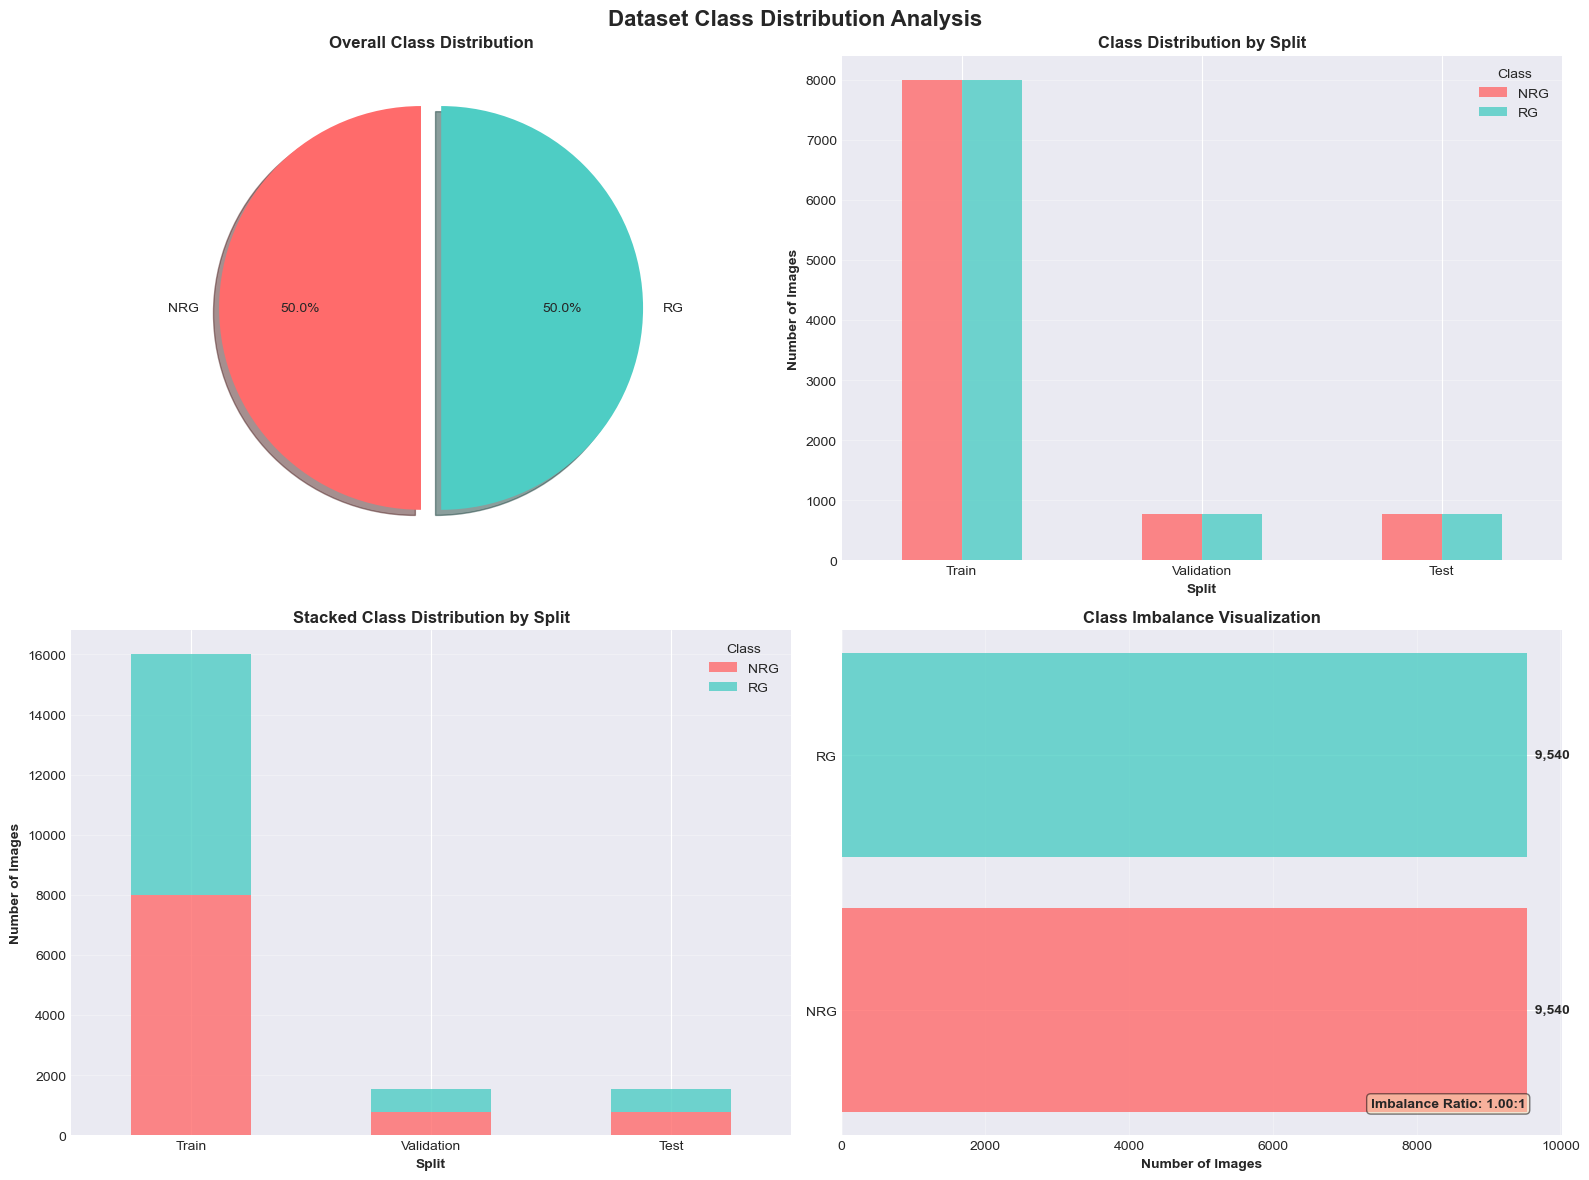

In [7]:
# Create visualizations
analyzer.visualize_distribution(save_path='dataset_distribution_analysis.png')

## 7. Export Dataset Statistics

In [8]:
# Export detailed statistics to JSON
analyzer.export_statistics('dataset_statistics.json')

# Display the exported statistics
with open('dataset_statistics.json', 'r') as f:
    stats = json.load(f)
    print("\nExported Statistics:")
    print(json.dumps(stats, indent=2))


✓ Statistics exported to: dataset_statistics.json

Exported Statistics:
{
  "timestamp": "2025-10-22T21:44:08.973932",
  "base_directory": "c:\\Users\\justi\\Downloads\\DATASCI5",
  "total_images": 19080,
  "class_distribution": {
    "NRG": 9540,
    "RG": 9540
  },
  "splits": {
    "train": {
      "NRG": 8000,
      "RG": 8000
    },
    "validation": {
      "NRG": 770,
      "RG": 770
    },
    "test": {
      "NRG": 770,
      "RG": 770
    }
  },
  "imbalance_ratio": 1.0,
  "minority_class": "NRG",
  "majority_class": "NRG",
  "class_weights": {
    "NRG": 1.0,
    "RG": 1.0
  }
}


## 8. Compare Balancing Strategies

In [9]:
# Initialize balancing strategy
balancer = ClassBalancingStrategy(analyzer)

# Compare all strategies
balancer.compare_strategies(save_path='balancing_strategies_comparison.csv')


CLASS BALANCING STRATEGIES COMPARISON

      Strategy  Training Samples  Data Loss                 Risk               Recommended
Undersampling             19080          0    High (loses data)                        No
 Oversampling             19080          0 Medium (overfitting) Maybe (with augmentation)
Class Weights             19080          0                  Low       Yes (best practice)

✓ Comparison saved to: balancing_strategies_comparison.csv

RECOMMENDATION FOR MEDICAL IMAGING

Use CLASS WEIGHTS strategy because:
  1. Preserves all valuable medical data
  2. No risk of overfitting from duplicates
  3. Mathematically proven approach
  4. Standard practice in medical AI
  5. Works with your augmentation pipeline

For best results, combine with:
  • Advanced data augmentation (see preprocessing notebook)
  • Focal loss (optional, for hard examples)
  • Proper evaluation metrics (F1, sensitivity, specificity)


## 9. Generate Class Weights Configuration (RECOMMENDED)

This is the **recommended approach** for your thesis project

In [10]:
# Generate class weights configuration
config = balancer.generate_class_weights_config('class_weights_config.json')

print("\n" + "="*80)
print("HOW TO USE IN YOUR MODELS")
print("="*80)
print("\nPyTorch Example:")
print("-" * 80)
print("import torch")
print("import torch.nn as nn")
print("import json")
print("")
print("# Load class weights")
print("with open('class_weights_config.json', 'r') as f:")
print("    config = json.load(f)")
print("    class_weights = config['class_weights_array']")
print("")
print("# Create weighted loss function")
print("weights = torch.FloatTensor(class_weights).cuda()  # or .cpu()")
print("criterion = nn.CrossEntropyLoss(weight=weights)")
print("")
print("# Use in training loop")
print("loss = criterion(outputs, labels)")
print("\nTensorFlow/Keras Example:")
print("-" * 80)
print("import json")
print("")
print("# Load class weights")
print("with open('class_weights_config.json', 'r') as f:")
print("    config = json.load(f)")
print("    class_weights = {int(k): v for k, v in config['class_to_index'].items()}")
print("")
print("# Use in model.fit()")
print("model.fit(x_train, y_train, class_weight=class_weights, ...)")


STRATEGY 3: CLASS WEIGHTS (RECOMMENDED)

Class Weights Configuration:
--------------------------------------------------------------------------------
  NRG            : 1.0000
  RG             : 1.0000

✓ Configuration saved to: class_weights_config.json

ADVANTAGES:
  • Preserves all training data
  • No artificial duplication
  • Computationally efficient
  • Standard practice in medical imaging

USAGE:
  Load these weights in your training script and apply to loss function

HOW TO USE IN YOUR MODELS

PyTorch Example:
--------------------------------------------------------------------------------
import torch
import torch.nn as nn
import json

# Load class weights
with open('class_weights_config.json', 'r') as f:
    config = json.load(f)
    class_weights = config['class_weights_array']

# Create weighted loss function
weights = torch.FloatTensor(class_weights).cuda()  # or .cpu()
criterion = nn.CrossEntropyLoss(weight=weights)

# Use in training loop
loss = criterion(outputs, la

## 10. Optional: Create Balanced Dataset (Undersampling)

**WARNING**: This reduces your training data. Only use if you have very large datasets.

In [11]:
# Uncomment to create undersampled balanced dataset
# balancer.create_balanced_dataset_undersampling(
#     output_dir='balanced_data_undersampled',
#     random_seed=42
# )

## 11. Optional: Create Balanced Dataset (Oversampling)

**WARNING**: This duplicates minority class images. Combine with strong augmentation to avoid overfitting.

In [12]:
# Uncomment to create oversampled balanced dataset
# balancer.create_balanced_dataset_oversampling(
#     output_dir='balanced_data_oversampled',
#     random_seed=42
# )

## 12. Summary and Recommendations

### What We Accomplished:
1. ✅ Comprehensive dataset analysis
2. ✅ Class imbalance quantification
3. ✅ Multiple balancing strategies evaluated
4. ✅ Class weights calculated and exported
5. ✅ Visualizations created

### For Your Thesis (4 Comparative Models):

**RECOMMENDED APPROACH:**
1. Use **class weights** (from `class_weights_config.json`) in all 4 models
2. Apply weights to your loss function during training
3. Combine with advanced data augmentation (next notebook)
4. Use proper evaluation metrics:
   - Sensitivity (Recall for RG class) - Most important for medical!
   - Specificity (Recall for NRG class)
   - F1-Score (balanced metric)
   - ROC-AUC
   - Confusion Matrix

### Why Class Weights?
- ✅ Preserves all valuable medical data
- ✅ No artificial duplication
- ✅ Standard practice in medical AI
- ✅ Works seamlessly with augmentation
- ✅ Mathematically sound

### Next Steps:
1. Proceed to enhanced preprocessing notebook (Ben Graham, vessel enhancement)
2. Implement class weights in your training code
3. Train all 4 models with identical class weights for fair comparison
4. Evaluate using medical-appropriate metrics

### Critical for Medical Imaging:
- **FALSE NEGATIVES** (missing glaucoma) are more dangerous than false positives
- Optimize for **high sensitivity** on RG (referable glaucoma) class
- Class weights help achieve this balance